# Phase 5-8. Opportunity Score - MVP Synthesis & Recommendation

Notebooks 01-03 built seven per-subsection variables into `bgri_master.gpkg`: `pop_density`,
`child_density`, `family_households_per_100_residents`, `private_schools_access_400m`,
`pct_university`, `pct_foreign_nationals`, and `dist_large_park_entrance_m`. Nothing so far has
turned those variables into an actual answer to the project's question - *where should this cafe
open?*

This notebook is a deliberate scope decision: rather than continuing to add variables
(Phase 2.3 property values, Phase 3.1 immediate family public realm, Phase 3.3 accessibility,
Phase 3.4 cultural amenities, and Phase 4 competition/tourism are all still open), it takes the
seven variables that already exist through the rest of the roadmap - distribution and correlation
checks (Phase 5), standardisation into thematic indices (Phase 6), a weighted opportunity score
with a sensitivity analysis (Phase 7), and a final recommendation (Phase 8).

The result is a complete, end-to-end MVP: thinner on inputs than the original roadmap envisioned,
but a full pipeline that produces a real score and a real recommendation, which the deferred
phases can then improve on rather than complete for the first time. See
`Documents/04_roadmap.md` for how the deferred phases are now sequenced as v2 work.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import contextily as ctx
import folium
from pathlib import Path

pd.set_option("display.width", 120)
sns.set_style("whitegrid")

# Porto's seven civil parishes (freguesias), keyed by the DTMNFR21 census code.
# Names verified by reverse-geocoding each parish's subsection centroids against
# OpenStreetMap/Nominatim; used to label the candidate areas in plain language.
FREGUESIA_NAMES = {
    "131202": "Bonfim",
    "131203": "Campanha",
    "131210": "Paranhos",
    "131211": "Ramalde",
    "131216": "Aldoar, Foz do Douro e Nevogilde",
    "131217": "Cedofeita / Santo Ildefonso / Se / Miragaia / S. Nicolau / Vitoria",
    "131218": "Lordelo do Ouro e Massarelos",
}

## Load the master layer

In [2]:
master_path = Path("../Data/Processed/bgri_master.gpkg")
gdf = gpd.read_file(master_path, layer="bgri")

print(f"Rows: {len(gdf)}")
print(f"CRS: {gdf.crs}")
print(f"Columns this notebook will read: "
      f"{['N_INDIVIDUOS', 'pop_density', 'child_density', 'family_households_per_100_residents', 'private_schools_access_400m', 'pct_university', 'pct_foreign_nationals', 'dist_large_park_entrance_m']}")

C:\Users\joani\.conda\envs\urban-intelligence-lab\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


Rows: 1659
CRS: EPSG:3763
Columns this notebook will read: ['N_INDIVIDUOS', 'pop_density', 'child_density', 'family_households_per_100_residents', 'private_schools_access_400m', 'pct_university', 'pct_foreign_nationals', 'dist_large_park_entrance_m']


## Defining the scored sample

A handful of BGRI subsections have zero resident population - riverbanks, the port, motorway
segments, industrial land, the Parque da Cidade itself. A location-suitability score for a
neighbourhood cafe is meaningless there: there is no "neighbourhood" to serve, and every
percentage-of-residents variable (`pct_university`, `pct_foreign_nationals`,
`family_households_per_100_residents`) is either `0/0` or undefined for them.

These subsections stay in `bgri_master.gpkg` (other notebooks may still use them), but they are
excluded from the scored sample built in this notebook, and their `opportunity_score` is left as
`NaN` rather than a misleading zero.

In [3]:
non_residential = gdf["N_INDIVIDUOS"] == 0
print(f"Zero-population subsections excluded from scoring: {non_residential.sum()} of {len(gdf)}")

scored = gdf.loc[~non_residential].copy()
print(f"Scored sample size: {len(scored)}")

Zero-population subsections excluded from scoring: 50 of 1659
Scored sample size: 1609


## 5.1 Explore distributions

For each of the seven candidate variables: histogram, descriptive stats, and skewness. Division-based
variables can produce `inf`/`-inf` when a denominator is zero; following the project convention, those
are treated as missing before any statistic is computed.

In [4]:
variables = [
    "pop_density",
    "child_density",
    "family_households_per_100_residents",
    "private_schools_access_400m",
    "pct_university",
    "pct_foreign_nationals",
    "dist_large_park_entrance_m",
]

labels = {
    "pop_density": "Population density\n(people/ha)",
    "child_density": "Child density\n(children/ha)",
    "family_households_per_100_residents": "Family households\nper 100 residents",
    "private_schools_access_400m": "Private schools\nwithin 400m",
    "pct_university": "University graduates\n(% of residents)",
    "pct_foreign_nationals": "Foreign nationals\n(% of residents)",
    "dist_large_park_entrance_m": "Distance to nearest\nlarge-park entrance (m)",
}

clean = scored[variables].replace([np.inf, -np.inf], np.nan)
print(f"Rows with at least one NaN across the seven variables: {clean.isna().any(axis=1).sum()}")

Rows with at least one NaN across the seven variables: 0


In [5]:
summary_rows = []
for var in variables:
    series = clean[var].dropna()
    summary_rows.append({
        "variable": var,
        "n": series.shape[0],
        "mean": series.mean(),
        "median": series.median(),
        "std": series.std(),
        "min": series.min(),
        "q25": series.quantile(0.25),
        "q75": series.quantile(0.75),
        "max": series.max(),
        "skew": stats.skew(series),
    })

summary = pd.DataFrame(summary_rows).set_index("variable").round(2)
summary

,n,mean,median,std,min,q25,q75,max,skew
variable,,,,,,,,,
pop_density,1609,95.15,78.30,75.66,0.12,37.82,132.54,576.96,1.44
child_density,1609,10.45,7.68,11.04,0.00,2.76,14.08,93.32,2.42
family_households_per_100_residents,1609,11.34,11.70,4.77,0.00,8.79,14.29,33.33,-0.28
private_schools_access_400m,1609,0.71,0.00,0.97,0.00,0.00,1.00,5.00,1.53
pct_university,1609,29.98,29.96,14.28,2.69,18.32,41.26,63.99,0.02
pct_foreign_nationals,1609,6.45,5.15,4.92,0.38,2.93,8.50,25.34,1.52
dist_large_park_entrance_m,1609,871.35,821.10,459.37,28.60,532.00,1143.80,2888.00,0.87


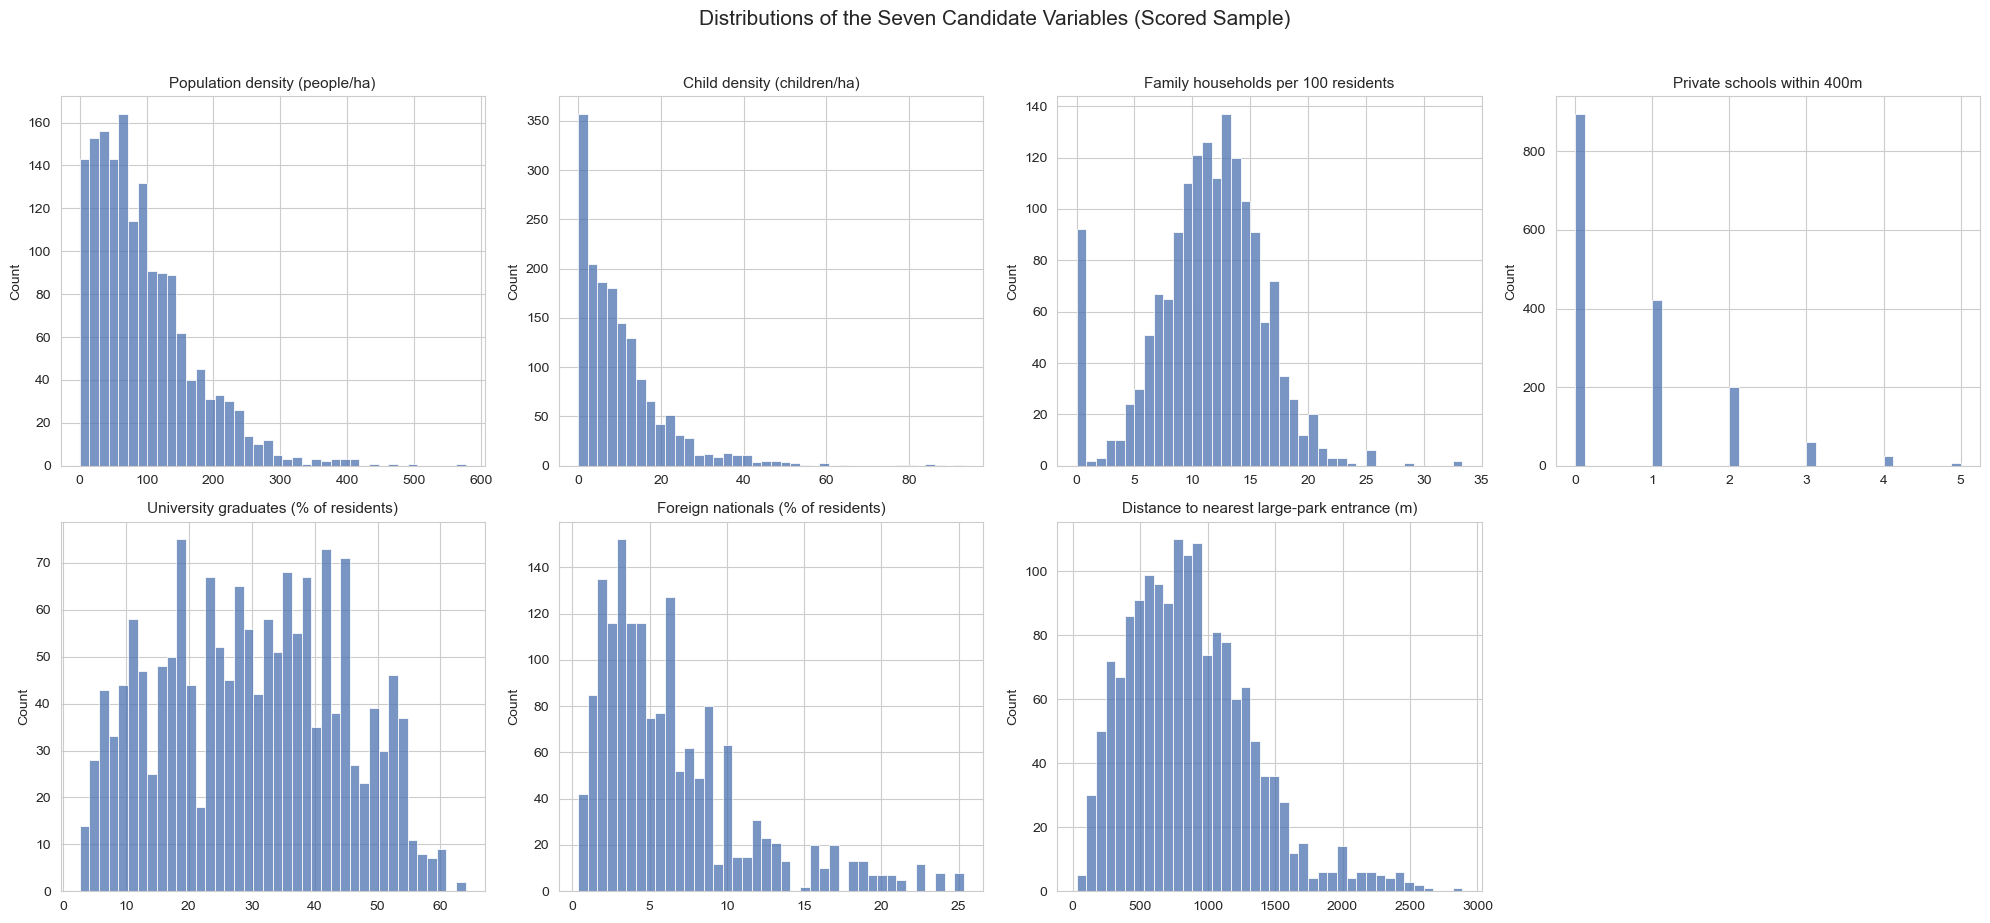

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    sns.histplot(clean[var].dropna(), bins=40, ax=ax, color="#4C72B0")
    ax.set_title(labels[var].replace("\n", " "), fontsize=11)
    ax.set_xlabel("")

axes[-1].axis("off")
plt.suptitle("Distributions of the Seven Candidate Variables (Scored Sample)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Reading the distributions:** most of these variables are right-skewed, which is typical for
counts and access measures - most subsections have a low-to-moderate value and a long tail of
outliers pulls the mean above the median. `private_schools_access_400m` is the most extreme case:
it is a count that is zero across most of the city and only positive near actual schools, so it
behaves like the roadmap's worked example (`0,0,0,0,0,1,1,2,7`) rather than a smooth
distribution. `dist_large_park_entrance_m` skews the other way in interpretation - lower is
better - but is still right-skewed in raw units (a short tail of subsections far from any large
park). None of this makes a variable unusable, but it does mean **rank-based** methods (min-max
on the observed range, Spearman correlation) are a safer default here than assuming normality.

## 5.2 Correlation analysis

Pearson and Spearman correlations across the seven variables, on the same NaN/inf-cleaned sample.
The goal is to catch redundancy before building indices - two variables that are nearly the same
signal shouldn't both get independent weight.

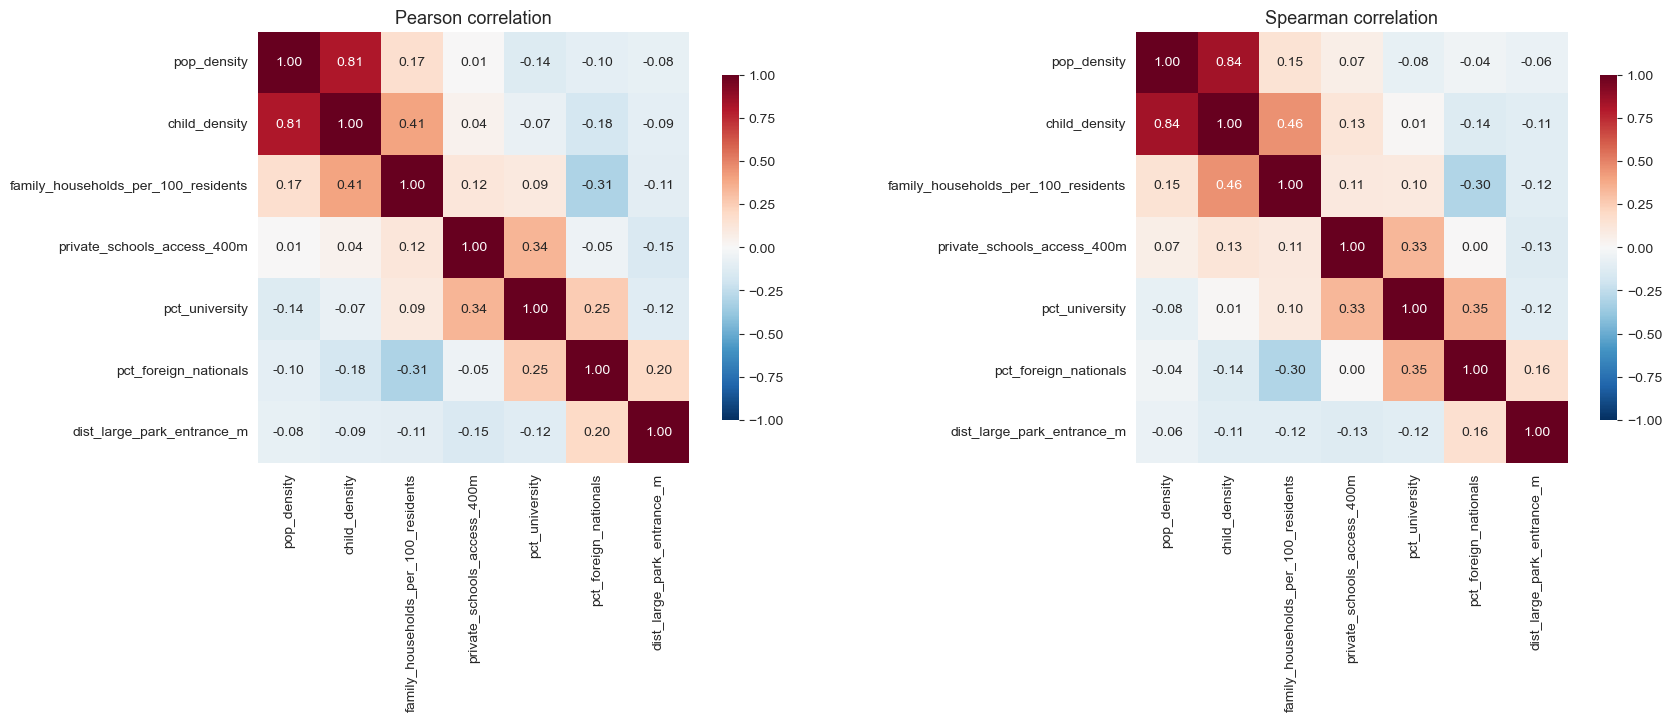

In [7]:
corr_input = clean.dropna()
pearson_corr = corr_input.corr(method="pearson")
spearman_corr = corr_input.corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    pearson_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    square=True, ax=axes[0], cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Pearson correlation", fontsize=13)

sns.heatmap(
    spearman_corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    square=True, ax=axes[1], cbar_kws={"shrink": 0.8}
)
axes[1].set_title("Spearman correlation", fontsize=13)

plt.tight_layout()
plt.show()

**Reading the correlations:** the strongest pair by far is `pop_density` and `child_density`
(Pearson 0.81, Spearman 0.84) - unsurprising, since a subsection with more people per hectare
tends to have more children per hectare too. This matters for the indices below: `pop_density`
feeds Demand alone, while `child_density` is one of three inputs to Family, so some of the
"family" signal is really the same demand signal restated. The other two Family inputs dilute
this - `family_households_per_100_residents` correlates with `pop_density` at only 0.17, and
`private_schools_access_400m` at just 0.01 - so the Family index isn't simply a copy of Demand,
but it isn't fully independent either. Two other relationships are worth flagging:
`family_households_per_100_residents` is moderately *negatively* correlated with
`pct_foreign_nationals` (-0.31/-0.30), and `private_schools_access_400m` correlates with
`pct_university` at 0.34/0.33 - a reasonable confirmation that school access and education level
are picking up a related affluence signal, consistent with the data dictionary's note that private
schools are a dual family/affluence indicator. `pct_university` and `pct_foreign_nationals` also
correlate positively (0.25/0.35), which cuts both ways for the "cosmopolitan but local" reading
flagged in 5.3 below - it's equally consistent with a tourism-adjacent story the model can't yet
distinguish. No pair is high enough (nothing above 0.84, and that one exception sits across two
different indices rather than within one) to force dropping a variable outright.

## 5.3 Variable selection

With only seven variables collected so far, the question isn't which ones to cut for
parsimony - it's whether any pair is so redundant that giving both independent weight would
double-count the same signal. Based on the correlation matrices above, all seven are kept for
this MVP pass. Two are worth flagging explicitly:

- **`pct_foreign_nationals`** is the weakest-justified indicator in the set. The concept-to-variable
  framework's closest match is "cosmopolitan but local" (Section 1), but a high foreign-national
  share can equally reflect tourism-adjacent turnover, which the framework treats as a *risk*
  factor (Section 2, penalty indicators), not a positive one. Without the Phase 4 tourism data to
  disambiguate the two readings, it is kept in the Affluence index (its closest available fit) but
  weighted no more heavily than any other single input, and flagged here so a future iteration
  with real tourism-intensity data can revisit it.
- **`private_schools_access_400m`** structurally straddles two categories (family and affluence per
  the data dictionary). It is scored once, under Family, to avoid crediting the same evidence
  twice under two different index names.

## 6. Standardisation

Min-max scaling to a common `[0, 1]` range, computed on the scored (residential) sample only -
the excluded zero-population subsections don't get to distort the range. `dist_large_park_entrance_m`
is inverted after scaling, since for this variable *lower is better*.

In [8]:
def min_max_scale(series):
    lo, hi = series.min(), series.max()
    return (series - lo) / (hi - lo)

for var in variables:
    scored[f"{var}_scaled"] = min_max_scale(scored[var].replace([np.inf, -np.inf], np.nan))

# Lower distance = better access, so invert after scaling.
scored["dist_large_park_entrance_m_scaled"] = 1 - scored["dist_large_park_entrance_m_scaled"]

scored[[f"{v}_scaled" for v in variables]].describe().round(2)

,pop_density_scaled,child_density_scaled,family_households_per_100_residents_scaled,private_schools_access_400m_scaled,pct_university_scaled,pct_foreign_nationals_scaled,dist_large_park_entrance_m_scaled
count,1609.00,1609.00,1609.00,1609.00,1609.00,1609.00,1609.00
mean,0.16,0.11,0.34,0.14,0.45,0.24,0.71
std,0.13,0.12,0.14,0.19,0.23,0.20,0.16
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.07,0.03,0.26,0.00,0.25,0.10,0.61
50%,0.14,0.08,0.35,0.00,0.44,0.19,0.72
75%,0.23,0.15,0.43,0.20,0.63,0.33,0.82
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 6.1 Thematic indices

Grouped following the concept-to-variable framework's categories, collapsed to fit what's actually
available (no walkability/transit data yet, so "Urban Quality" stands in for the framework's
walkability + lifestyle categories until Phase 3.1/3.3/3.4 land):

| Index | Variables | Concept-to-variable link |
|---|---|---|
| Demand | `pop_density` | "Regular local customers" -> residential density |
| Family | `child_density`, `family_households_per_100_residents`, `private_schools_access_400m` | "Family-oriented atmosphere", "child-friendly use" |
| Urban Quality | `dist_large_park_entrance_m` (inverted) | "Customers who linger" -> proximity to public space |
| Affluence | `pct_university`, `pct_foreign_nationals` | "Moderate premium pricing" -> purchasing-power proxy |

In [9]:
scored["demand_index"] = scored["pop_density_scaled"]

scored["family_index"] = scored[[
    "child_density_scaled",
    "family_households_per_100_residents_scaled",
    "private_schools_access_400m_scaled",
]].mean(axis=1)

scored["urban_quality_index"] = scored["dist_large_park_entrance_m_scaled"]

scored["affluence_index"] = scored[[
    "pct_university_scaled",
    "pct_foreign_nationals_scaled",
]].mean(axis=1)

index_cols = ["demand_index", "family_index", "urban_quality_index", "affluence_index"]
scored[index_cols].describe().round(2)

,demand_index,family_index,urban_quality_index,affluence_index
count,1609.00,1609.00,1609.00,1609.00
mean,0.16,0.20,0.71,0.34
std,0.13,0.10,0.16,0.17
min,0.00,0.00,0.00,0.01
25%,0.07,0.13,0.61,0.20
50%,0.14,0.19,0.72,0.36
75%,0.23,0.26,0.82,0.46
max,1.00,0.66,1.00,0.78


## 6.2 Weighting strategy

Baseline weights for the "everyday neighbourhood cafe" scenario described in the project brief:

| Index | Weight | Reasoning |
|---|---|---|
| Demand | 35% | Without enough residents nearby to become regulars, nothing else in the concept works - this is the foundation, not just one factor among equals. |
| Family | 25% | The concept is explicitly family-oriented (children's corner, family routes); this is a core differentiator, not a secondary bonus. |
| Urban Quality | 25% | "Customers who linger" depends on a pleasant nearby environment - weighted equal to Family since both define this specific concept against a generic cafe. |
| Affluence | 15% | The brief targets *moderate* premium pricing, not a luxury positioning, so affluence is a viability floor rather than the primary driver - and it's built on the weakest-evidenced variable in the set (see 5.3). |

There is no objectively correct split here; this one is documented so it can be argued with and
revised, which is exactly what Section 7.1 does next.

In [10]:
BASELINE_WEIGHTS = {
    "demand_index": 0.35,
    "family_index": 0.25,
    "urban_quality_index": 0.25,
    "affluence_index": 0.15,
}
assert abs(sum(BASELINE_WEIGHTS.values()) - 1.0) < 1e-9

## 7. Opportunity score calculation

`opportunity_score = 100 x weighted sum of the four indices`, computed for the scored sample only;
excluded zero-population subsections keep `opportunity_score = NaN`.

count    1609.0
mean       33.5
std         7.9
min         6.7
25%        28.2
50%        33.7
75%        38.5
max        66.4
Name: opportunity_score, dtype: float64


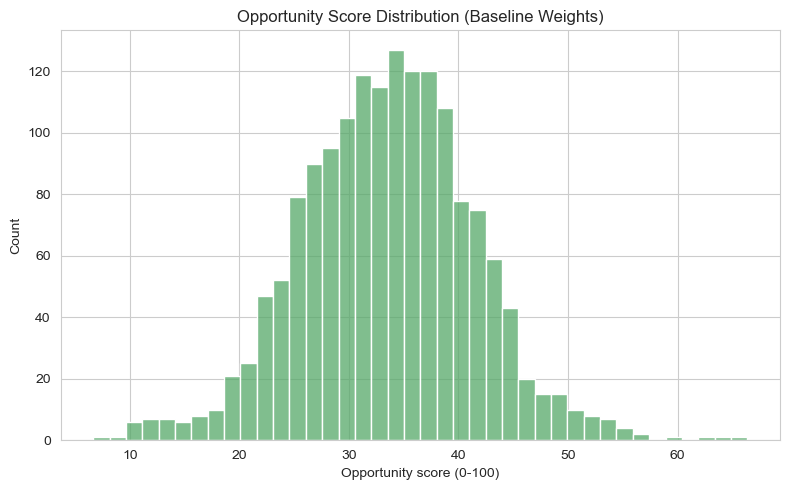

In [11]:
def weighted_score(df, weights):
    return sum(df[idx] * w for idx, w in weights.items()) * 100

scored["opportunity_score"] = weighted_score(scored, BASELINE_WEIGHTS)

print(scored["opportunity_score"].describe().round(1))

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(scored["opportunity_score"], bins=40, ax=ax, color="#55A868")
ax.set_title("Opportunity Score Distribution (Baseline Weights)")
ax.set_xlabel("Opportunity score (0-100)")
plt.tight_layout()
plt.show()

## 7.1 Sensitivity analysis

Two alternate weighting scenarios, built from the same four indices, to see which areas depend on
the baseline's specific judgement calls versus which perform well no matter how the dimensions are
weighted. (A third "remote worker" scenario from the roadmap's original sketch is skipped here -
its natural inputs, coworking spaces and cafe-friendly amenity mix, are Phase 3.4 variables that
don't exist yet.)

In [12]:
SCENARIO_WEIGHTS = {
    "baseline": BASELINE_WEIGHTS,
    "family_focused": {
        "demand_index": 0.25,
        "family_index": 0.45,
        "urban_quality_index": 0.20,
        "affluence_index": 0.10,
    },
    "premium_focused": {
        "demand_index": 0.25,
        "family_index": 0.15,
        "urban_quality_index": 0.20,
        "affluence_index": 0.40,
    },
}

for name, weights in SCENARIO_WEIGHTS.items():
    assert abs(sum(weights.values()) - 1.0) < 1e-9
    col = "opportunity_score" if name == "baseline" else f"opportunity_score_{name}"
    scored[col] = weighted_score(scored, weights)

score_cols = ["opportunity_score", "opportunity_score_family_focused", "opportunity_score_premium_focused"]
scored[score_cols].describe().round(1)

,opportunity_score,opportunity_score_family_focused,opportunity_score_premium_focused
count,1609.0,1609.0,1609.0
mean,33.5,30.6,35.0
std,7.9,7.9,8.3
min,6.7,5.1,8.7
25%,28.2,25.2,28.6
50%,33.7,30.3,36.0
75%,38.5,36.0,41.4
max,66.4,65.1,59.4


In [13]:
rank_corr = scored[score_cols].corr(method="spearman")
print("Spearman rank correlation between scenarios:")
print(rank_corr.round(3))

top_decile_sets = {
    col: set(scored.loc[scored[col] >= scored[col].quantile(0.9), "BGRI2021"])
    for col in score_cols
}

print("\nTop-decile overlap (Jaccard index) vs baseline:")
baseline_top = top_decile_sets["opportunity_score"]
for col in score_cols[1:]:
    other = top_decile_sets[col]
    jaccard = len(baseline_top & other) / len(baseline_top | other)
    print(f"  {col}: {jaccard:.2f} ({len(baseline_top & other)} of {len(baseline_top)} baseline top-decile subsections also top-decile here)")

Spearman rank correlation between scenarios:
                                   opportunity_score  opportunity_score_family_focused  \
opportunity_score                              1.000                             0.966   
opportunity_score_family_focused               0.966                             1.000   
opportunity_score_premium_focused              0.789                             0.711   

                                   opportunity_score_premium_focused  
opportunity_score                                              0.789  
opportunity_score_family_focused                               0.711  
opportunity_score_premium_focused                              1.000  

Top-decile overlap (Jaccard index) vs baseline:
  opportunity_score_family_focused: 0.62 (123 of 161 baseline top-decile subsections also top-decile here)
  opportunity_score_premium_focused: 0.43 (97 of 161 baseline top-decile subsections also top-decile here)


**Reading the sensitivity results:** the family-focused scenario tracks the baseline closely
(Spearman 0.966, 62% of the baseline's 161 top-decile subsections still top-decile there) - the
baseline already weights Family second-highest, so pushing it further mostly reorders within the
same set of areas rather than picking new ones. The premium-focused scenario moves much more
(Spearman 0.789, only 43% top-decile overlap): more than half the baseline's top-decile
subsections drop out when affluence is weighted at 40%, meaning a real share of the baseline's
recommendation depends on Demand/Family/Urban Quality rather than pure purchasing power - areas
that are "good enough" on affluence but win mainly on residential demand and park access. That
split is informative on its own: it shows the baseline recommendation isn't just a proxy for "rich
neighbourhoods," and it flags which subsections are baseline-only picks worth a second look before
committing to one (the 64 subsections in the premium-focused top decile that aren't in the
baseline's are worth inspecting specifically for that reason).

## 7.2 Spatial visualisation

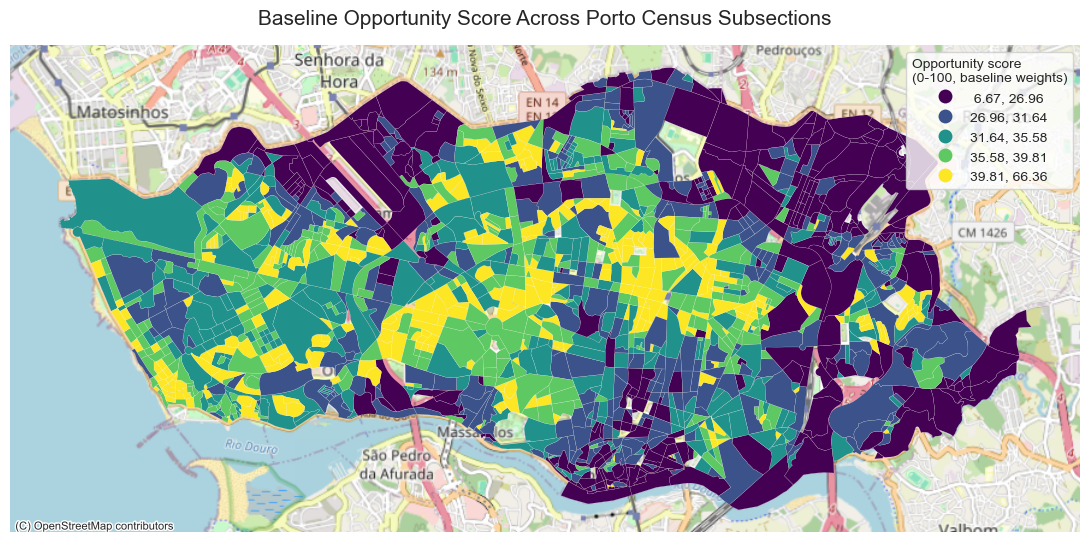

In [14]:
fig, ax = plt.subplots(figsize=(11, 11))

scored.plot(
    column="opportunity_score",
    scheme="quantiles",
    k=5,
    cmap="viridis",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=ax,
    legend_kwds={"title": "Opportunity score\n(0-100, baseline weights)"},
)

ctx.add_basemap(ax, crs=scored.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Baseline Opportunity Score Across Porto Census Subsections", fontsize=15, pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()

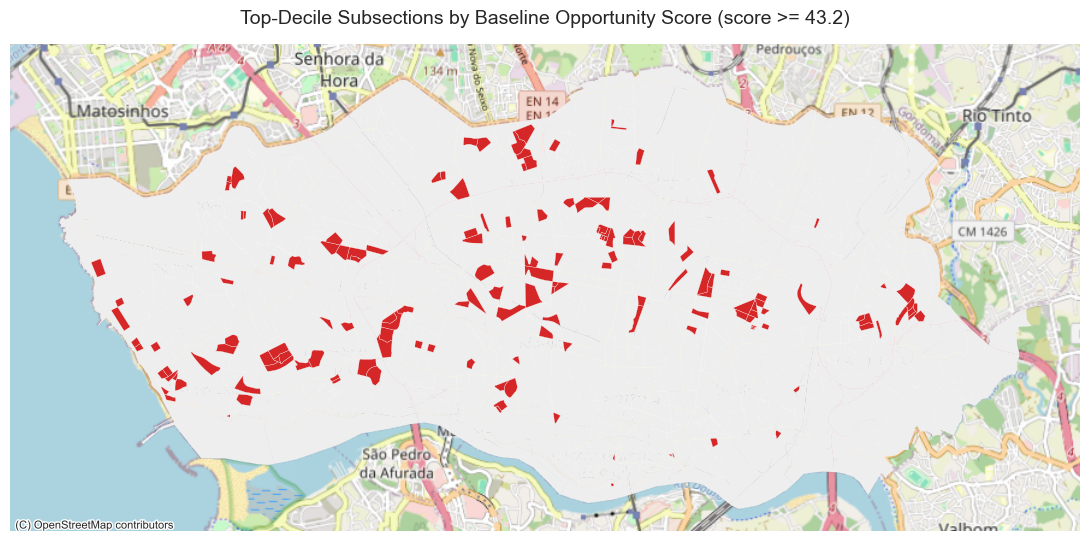

In [15]:
top_decile_cutoff = scored["opportunity_score"].quantile(0.9)
scored["top_decile"] = scored["opportunity_score"] >= top_decile_cutoff

fig, ax = plt.subplots(figsize=(11, 11))

gdf.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)
scored[scored["top_decile"]].plot(ax=ax, color="#D62728", edgecolor="white", linewidth=0.2)

ctx.add_basemap(ax, crs=scored.crs, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title(
    f"Top-Decile Subsections by Baseline Opportunity Score (score >= {top_decile_cutoff:.1f})",
    fontsize=14, pad=15
)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [16]:
scored_wgs84 = scored.to_crs(4326)

m = folium.Map(location=[41.1579, -8.6291], zoom_start=12, tiles="cartodbpositron")

score_layers = [
    ("Baseline opportunity score", "opportunity_score", "YlGn"),
    ("Family-focused opportunity score", "opportunity_score_family_focused", "YlOrBr"),
    ("Premium-focused opportunity score", "opportunity_score_premium_focused", "PuBuGn"),
]

for name, column, color in score_layers:
    is_baseline = name == "Baseline opportunity score"
    choropleth = folium.Choropleth(
        geo_data=scored_wgs84[["BGRI2021", column, "geometry"]],
        data=scored_wgs84,
        columns=["BGRI2021", column],
        key_on="feature.properties.BGRI2021",
        fill_color=color,
        fill_opacity=0.75,
        line_opacity=0.1,
        legend_name=name,
        name=name,
        show=is_baseline,
    )
    # Folium renders every Choropleth's colour scale at once regardless of which layer
    # is toggled on, so the three legends stack and overlap. Keep only the baseline's.
    if not is_baseline:
        for key in list(choropleth._children):
            if key.startswith("color_map"):
                del choropleth._children[key]
    choropleth.add_to(m)

# Explicit marker layer for the top-15 candidate subsections, so the recommended
# areas are directly visible and clickable rather than only inferable from the
# shading. Each popup names the parish (freguesia) and shows the sub-index breakdown.
candidates = scored.sort_values("opportunity_score", ascending=False).head(15).copy()
candidate_centroids = candidates.geometry.centroid.to_crs(4326)
candidates_layer = folium.FeatureGroup(name="Top 15 candidate areas", show=True)
for rank, (idx, row) in enumerate(candidates.iterrows(), start=1):
    pt = candidate_centroids.loc[idx]
    freg = FREGUESIA_NAMES.get(str(row["DTMNFR21"]), str(row["DTMNFR21"]))
    popup_html = (
        f"<b>#{rank} &middot; score {row['opportunity_score']:.1f}</b><br>"
        f"<b>{freg}</b><br>"
        f"<small>subsection {row['BGRI2021']}</small>"
        f"<hr style='margin:5px 0'>"
        f"Demand {row['demand_index']:.2f} &middot; Family {row['family_index']:.2f}<br>"
        f"Urban quality {row['urban_quality_index']:.2f} &middot; Affluence {row['affluence_index']:.2f}"
    )
    folium.Marker(
        location=[pt.y, pt.x],
        tooltip=f"#{rank} - {freg.split(' /')[0]} ({row['opportunity_score']:.0f})",
        popup=folium.Popup(popup_html, max_width=300),
        icon=folium.Icon(color="darkred", icon="star"),
    ).add_to(candidates_layer)
candidates_layer.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

map_path = Path("../Maps/opportunity_score_map.html")
m.save(str(map_path))
print(f"Saved {map_path}")

Saved ..\Maps\opportunity_score_map.html


## 7.3 Ground-truth and competition check (deferred, noted honestly)

The roadmap's Phase 7.3 asks whether known successful neighbourhood cafes already exist in
high-scoring areas - a genuine external-validity check. That check needs a real, geocoded dataset
of existing cafes (Phase 4, not started) and is not something to approximate from memory: a list of
"neighbourhoods known for cafes" recalled without a dataset behind it isn't a validation, it's a
guess wearing validation's clothes.

This is logged here as the clearest, most valuable next step for v2, not skipped silently: collect
existing cafe locations (e.g. OSM `amenity=cafe`, matching the project's existing OSMnx pattern from
Notebook 3), join them to this notebook's `opportunity_score`, and check whether the two agree,
disagree, or reveal a saturation story in the top-scoring areas.

## 8. Final recommendation

Top-15 subsections by baseline opportunity score, with their parish (freguesia), sub-index
breakdown, and centroid coordinates (WGS84). Parish names come from reverse-geocoding each
subsection's centroid against OpenStreetMap/Nominatim — a lightweight verification that is enough
to name areas; a fully rigorous version would join the subsections to the official CAOP
administrative-boundary polygons.

In [17]:
top15 = scored.sort_values("opportunity_score", ascending=False).head(15).copy()
top15_centroids = top15.geometry.centroid.to_crs(4326)
top15["lon"] = top15_centroids.x.values
top15["lat"] = top15_centroids.y.values
top15["freguesia"] = top15["DTMNFR21"].astype(str).map(FREGUESIA_NAMES)

display_cols = [
    "BGRI2021", "freguesia", "opportunity_score", "demand_index", "family_index",
    "urban_quality_index", "affluence_index", "lat", "lon",
]
top15[display_cols].round(3).reset_index(drop=True)

,BGRI2021,freguesia,opportunity_score,demand_index,family_index,urban_quality_index,affluence_index,lat,lon
0,13121600907,"Aldoar, Foz do Douro e Nevogilde",66.365,0.771,0.592,0.835,0.246,41.173,-8.667
1,13121001102,Paranhos,64.490,0.867,0.600,0.698,0.113,41.179,-8.612
2,13120300204,Campanha,62.546,0.817,0.499,0.851,0.013,41.159,-8.570
3,13121701401,Cedofeita / Santo Ildefonso / Se / Miragaia / ...,59.515,0.650,0.509,0.612,0.582,41.144,-8.612
4,13120303002,Campanha,57.382,0.704,0.334,0.952,0.040,41.158,-8.574
5,13121802411,Lordelo do Ouro e Massarelos,56.888,0.668,0.280,0.935,0.208,41.149,-8.628
6,13121801703,Lordelo do Ouro e Massarelos,55.912,0.544,0.419,0.935,0.201,41.154,-8.659
7,13121100801,Ramalde,54.801,0.581,0.339,0.841,0.330,41.177,-8.626
8,13121003303,Paranhos,54.630,0.714,0.210,0.885,0.150,41.175,-8.625
9,13121705207,Cedofeita / Santo Ildefonso / Se / Miragaia / ...,54.571,1.000,0.216,0.520,0.077,41.141,-8.612


**Where the top candidates actually are.** The 161 top-decile subsections spread across all
seven Porto parishes, most heavily in Paranhos (30 subsections), Aldoar/Foz/Nevogilde (29),
Campanha and Lordelo do Ouro/Massarelos (25 each), the Cedofeita/historic-centre union (24),
Ramalde (19), and Bonfim (9). But "top decile" and "best fit for *this* concept" aren't the same
thing - once the sub-index breakdown is read, two areas stand out for opposite reasons, and one
high-scoring area is a deliberate *non*-recommendation:

- **Aldoar (west, bordering Parque da Cidade)** - `131216`, subsection `13121600907`, the single
  highest score in the city (66/100). Strong Urban Quality (0.84, it sits beside Porto's largest
  urban park) and Demand (0.77), with only moderate Affluence (0.25). This is the strongest
  *family / lingering* candidate - it wins on the parts of the concept that make it a neighbourhood
  café rather than a generic one.
- **Cedofeita (central Porto)** - `131217`, the historic-centre union, holds the densest cluster of
  *affluence-led* candidates (a run of subsections around Cedofeita / Santo Ildefonso with
  Affluence 0.53-0.63). This is the clearest **"moderate premium"** fit. Note the standout
  `13121701401` (score 59.5, Affluence 0.58) is specifically the **Ribeira riverfront** in the
  historic core - a single high-affluence subsection rather than a whole district, so it's a
  notable spot rather than the cluster itself.
- **Campanha (east) - scores high but is the weakest fit.** `131203` contributes four of the top 15
  on the strength of Demand and Urban Quality, but its Affluence is near zero (0.01-0.04). For a
  concept that needs *moderate premium* pricing, high footfall alone doesn't carry it - this is the
  clearest example of why the raw score has to be read through the sub-indices, not taken flat.

**Recommendation:** start with **Aldoar** (family/urban-quality strength) and **Cedofeita**
(purchasing-power viability) - the two areas that each win on a different half of what this specific
concept needs. Treat Campanha's high scores with caution until the affluence gap is understood.

Parish names above were verified by reverse-geocoding subsection centroids against
OpenStreetMap/Nominatim. Before any site visit, the rigorous next step is a full join to the
official CAOP administrative-boundary polygons (rather than centroid geocoding), plus the Phase 4
competition check - see §7.3.

### Export to GeoPackage

Saves this notebook's full enriched sample to `Data/Processed/04_bgri_opportunity_score.gpkg`,
then accumulates its own columns into the shared `Data/Processed/bgri_master.gpkg` layer. Following
the established pattern, the excluded zero-population subsections are merged back in with
`opportunity_score` (and the other owned columns) left as `NaN` - they stay in the master's row
count, they just don't get a score.

In [18]:
processed_dir = Path("../Data/Processed")
processed_dir.mkdir(parents=True, exist_ok=True)

scored.to_file(processed_dir / "04_bgri_opportunity_score.gpkg", driver="GPKG")

own_cols = [
    "demand_index",
    "family_index",
    "urban_quality_index",
    "affluence_index",
    "opportunity_score",
    "opportunity_score_family_focused",
    "opportunity_score_premium_focused",
]

master = gpd.read_file(master_path, layer="bgri")
before_shape = master.shape

master = master.drop(columns=[c for c in own_cols if c in master.columns])
master = master.merge(scored[["BGRI2021"] + own_cols], on="BGRI2021", how="left")

master.to_file(master_path, driver="GPKG", layer="bgri")

print(f"Updated {master_path.name}")
print(f"Previous shape: {before_shape}")
print(f"Updated shape: {master.shape}")
print(f"Updated variables: {own_cols}")
print(f"\nRows with non-null opportunity_score: {master['opportunity_score'].notna().sum()} of {len(master)}")

Updated bgri_master.gpkg
Previous shape: (1659, 67)
Updated shape: (1659, 67)
Updated variables: ['demand_index', 'family_index', 'urban_quality_index', 'affluence_index', 'opportunity_score', 'opportunity_score_family_focused', 'opportunity_score_premium_focused']

Rows with non-null opportunity_score: 1609 of 1659
